## Use Masks to help guide the image generation process 
### A mask is a black and white image with 255 (white) where the generator is aloud to generate, and 0 (black) where the generator is not. Most models listen to mask to a certain digree. But models exists like there that listen to masks 100% like FidDit. 
https://github.com/BoyuanJiang/FitDiT

In [ ]:
import sys
! pip install ipykernel
!{sys.executable} -m pip install torch diffusers transformers accelerate safetensors matplotlib Pillow ipython

In [16]:
import torch
from PIL import Image
import requests
from io import BytesIO
import numpy as np 
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch.nn as nn

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


In [ ]:

def predict_mask(model, processor, product_image):

    """
    Parameters
    ----------
    model: masking model
    processor: masking processor
    product_image: image to be maskes

    Returns
    -------
    all masks in the form of a dict
    The masks are:
    
    """

    # Get the predicted mask in the form logits (the output of the model before applying argmax)
    inputs = processor(images=product_image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    logits = outputs.logits

    upsampled_logits = nn.functional.interpolate(
        logits,
        size=product_image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    predicted_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

    # The predicted mask is a 2D array where each pixel's value corresponds to the predicted class label for that pixel.
    # TOPS
    predicted_top = predicted_mask == 4

    #BOTTOMS
    predicted_skirt = predicted_mask == 5
    predicted_pants = predicted_mask == 6
    predicted_bottoms = predicted_skirt + predicted_pants

    #DRESSES
    predicted_dress = predicted_mask == 7

    masks = {
        "Tops": predicted_top,
        "Bottoms": predicted_bottoms,
        "Dresses & Sets": predicted_dress,
        }
    return masks

In [ ]:
# Load the Pipeline fot inpainting

from diffusers import StableDiffusionInpaintPipeline
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting"
).to(device)


In [ ]:
# Load Masking Model and the processor for the model. 
# The processor is used to preprocess the input image before feeding it to the model and postprocess the output of the model 
# to get the predicted mask.

masking_processor = SegformerImageProcessor.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = AutoModelForSemanticSegmentation.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = masking_model.to(device)

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

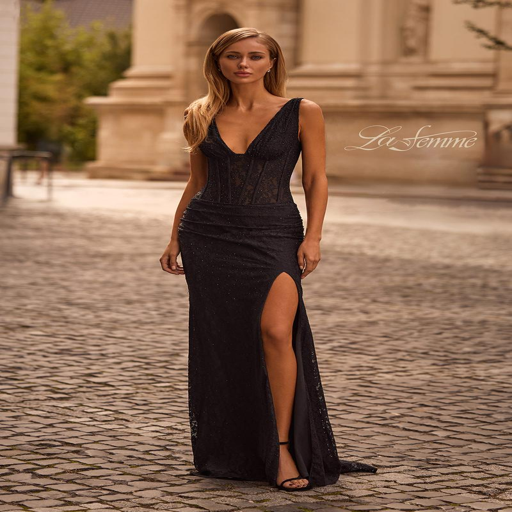

In [ ]:
# Get the input image and display it 

url = "https://www.terrycosta.com/cdn/shop/files/32943_Black_F_Editorial_810x.jpg?v=1733181803"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))
display(init_image)


In [ ]:
# Mask the image 
# This returns a dict of masks for each category (Tops, Bottoms, Dresses & Sets) 
# where each mask is a binary image with the same size as the input image.
# In this purticular case, the Tops and Bottoms are a black canvas because they are not present in the input image. 

masked_images = predict_mask(masking_model, masking_processor, init_image)
print(masked_images.keys())

dict_keys(['Tops', 'Bottoms', 'Dresses & Sets'])


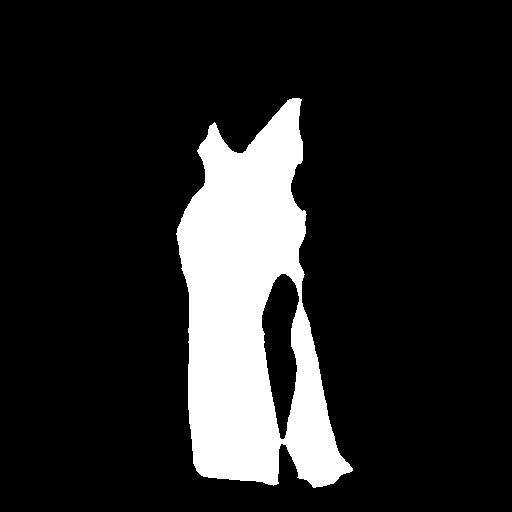

In [ ]:
mask = masked_images['Dresses & Sets']
mask = np.where(mask > 0, 255, 0).astype(np.uint8)
mask = Image.fromarray(mask)
display(mask)

In [ ]:
# Give the mask to the model for guidance. 
# The model will mostly only edit the pixels that are masked.

edited = pipe(prompt='change the dress color to a monochrome blue dress', image=init_image, mask_image=mask).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

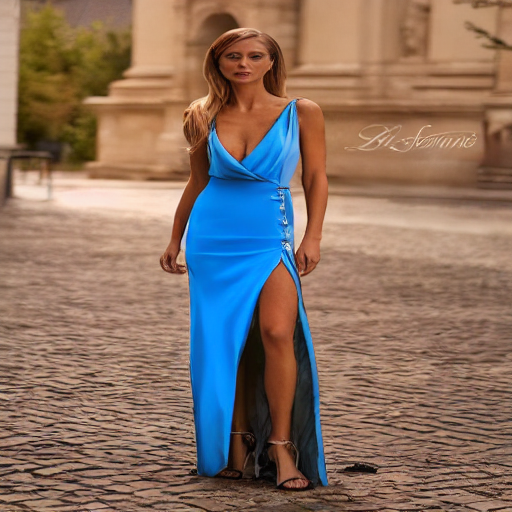

In [36]:
display(edited)